In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import umap

c:\Users\sebas\Documents\VS_Studio_code\modelo_computacional\Modelo_computacional\entorno_virtual\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_clusters = pd.read_pickle("documentos_2004_2024_preprocesados.pkl")

print("Shape:", df_clusters.shape)
print("Tipo de resuelve_tokens:", type(df_clusters["resuelve_tokens"].iloc[0]))
print(df_clusters["resuelve_tokens"].head(3).to_list())

Shape: (23518, 8)
Tipo de resuelve_tokens: <class 'list'>
[['modificar', 'prestacion', 'servicios', 'salud', 'sistema', 'seguridad', 'social'], ['aprobar', 'presupuesto', 'fondos', 'generales', 'vigencia', 'fiscal'], ['aprobar', 'presupuesto', 'fondos', 'seguridad', 'social', 'vigencia', 'fiscal']]


In [3]:
df_clusters["resuelve_doc"] = df_clusters["resuelve_tokens"].apply(lambda toks: " ".join(toks))

print(df_clusters["resuelve_doc"].head(3).to_list())

['modificar prestacion servicios salud sistema seguridad social', 'aprobar presupuesto fondos generales vigencia fiscal', 'aprobar presupuesto fondos seguridad social vigencia fiscal']


In [4]:
docs = df_clusters["resuelve_doc"].fillna("").tolist()

model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(model_name)

embeddings = embedder.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Shape embeddings:", embeddings.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1583.47it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 368/368 [06:21<00:00,  1.04s/it]


Shape embeddings: (23518, 384)


In [5]:
# Guardado opcional para no recalcular
np.save("embeddings_resuelve_umap3_2.npy", embeddings)

In [6]:
reducer = umap.UMAP(
    n_neighbors=15, # significa que cada punto se conectará a sus 15 vecinos más cercanos
    n_components=5, # número de dimensiones a reducir (en este caso, 5)
    metric="cosine",# la métrica de distancia a utilizar (en este caso, coseno)
    random_state=42 # significa que el resultado será reproducible, ya que se fija la semilla del generador de números aleatorios
)

embeddings_reducidos = reducer.fit_transform(embeddings)

print("Shape embeddings reducidos:", embeddings_reducidos.shape)

c:\Users\sebas\Documents\VS_Studio_code\modelo_computacional\Modelo_computacional\entorno_virtual\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape embeddings reducidos: (23518, 5)


In [7]:
# Guardar embeddings reducidos
np.save("embeddings_resuelve_umap3_2.npy", embeddings_reducidos)

In [8]:
resultados_kmeans = []

for k in range(5, 31):
    modelo = KMeans(
        n_clusters=k,        # cantidad de clusters a probar
        random_state=42,     # hace reproducible el resultado
        n_init=20            # múltiples inicializaciones, escoge la mejor por inercia
    )
    labels = modelo.fit_predict(embeddings_reducidos)
    resultados_kmeans.append({
        "k": k,
        "inercial": modelo.inertia_
    })

# Convertir a DataFrame
resultados_kmeans = pd.DataFrame(resultados_kmeans)

print(resultados_kmeans)

     k       inercial
0    5  213210.093750
1    6  187206.125000
2    7  165326.125000
3    8  144825.015625
4    9  133504.281250
5   10  122408.562500
6   11  111735.726562
7   12  103478.039062
8   13   96771.789062
9   14   90401.484375
10  15   85612.515625
11  16   80643.593750
12  17   77506.882812
13  18   73552.703125
14  19   69319.546875
15  20   66472.890625
16  21   63165.593750
17  22   60239.425781
18  23   56968.886719
19  24   54412.609375
20  25   51332.234375
21  26   49760.109375
22  27   47255.734375
23  28   45748.281250
24  29   42019.910156
25  30   40266.804688


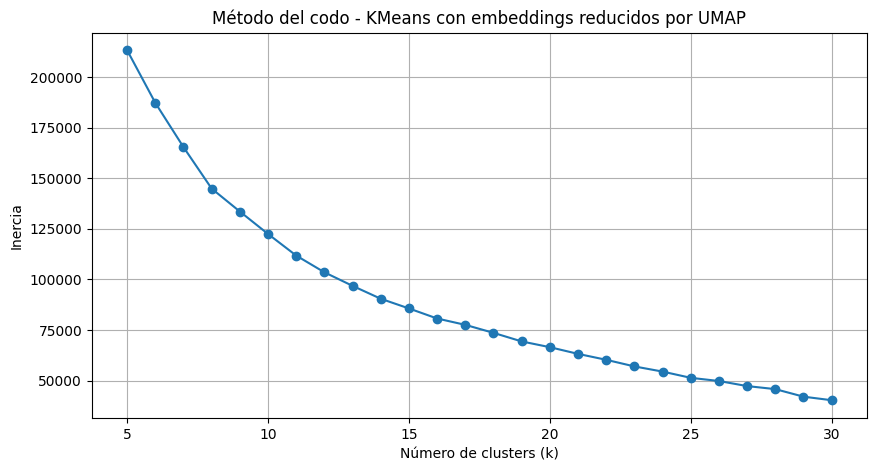

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(resultados_kmeans["k"], resultados_kmeans["inercial"], marker="o")
plt.title("Método del codo - KMeans con embeddings reducidos por UMAP")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [10]:
resultados_kmeans.to_excel("resultados_kmeans_umap3_2.xlsx", index=False)
resultados_kmeans.to_csv("resultados_kmeans_umap3_2.csv", index=False)

In [11]:
best_k = 10

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df_clusters["cluster_kmeans"] = kmeans_final.fit_predict(embeddings_reducidos)

print(df_clusters["cluster_kmeans"].value_counts().sort_index())

cluster_kmeans
0    4494
1    1985
2    2716
3     114
4     158
5    3626
6     861
7     113
8    5390
9    4061
Name: count, dtype: int64


In [12]:
for c in sorted(df_clusters["cluster_kmeans"].unique()):
    print(f"\n===== CLUSTER KMEANS {c} =====")
    
    muestra = df_clusters.loc[
        df_clusters["cluster_kmeans"] == c,
        ["resuelve", "resuelve_tokens"]
    ].head(8) 

    for _, fila in muestra.iterrows():
        print("Texto:", fila["resuelve"])
        print("Tokens:", fila["resuelve_tokens"])
        print("-" * 100)


===== CLUSTER KMEANS 0 =====
Texto: sustituir acuerdo academico 0005 del 24 de mayo de 1994 reglamenta programa de cursos semipresenciales
Tokens: ['sustituir', 'academico', 'reglamenta', 'programa', 'cursos', 'semipresenciales']
----------------------------------------------------------------------------------------------------
Texto: sustituir acuerdos academicos 0091 del 15 de abril de 1997 0152 del 27 de octubre de 1999 y 221 del 11 de septiembre de 2002 competencia en lengua extranjera en posgrados
Tokens: ['sustituir', 'acuerdos', 'academicos', 'competencia', 'lengua', 'extranjera', 'posgrados']
----------------------------------------------------------------------------------------------------
Texto: modificar articulo 3 acuerdo superior 131 de 1998 exenciones pago de matricula
Tokens: ['modificar', 'exenciones', 'pago', 'matricula']
----------------------------------------------------------------------------------------------------
Texto: crear programa de pregrado gestion cul

In [13]:
df_clusters.to_pickle("documentos_clusterizados_kmeans_umap3_2.pkl")
df_clusters.to_excel("documentos_clusterizados_kmeans_umap3_2.xlsx", index=False)

In [2]:
df_clusters = pd.read_pickle("documentos_clusterizados_kmeans_umap3_2.pkl")
embeddings = np.load("embeddings_resuelve_umap3_2.npy")

In [3]:
print(type(embeddings))
print(embeddings.shape)

<class 'numpy.ndarray'>
(23518, 5)


In [4]:
from sklearn.decomposition import PCA

C:\Users\sebas\AppData\Local\Temp\ipykernel_10476\3033743669.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(clusters_ordenados))


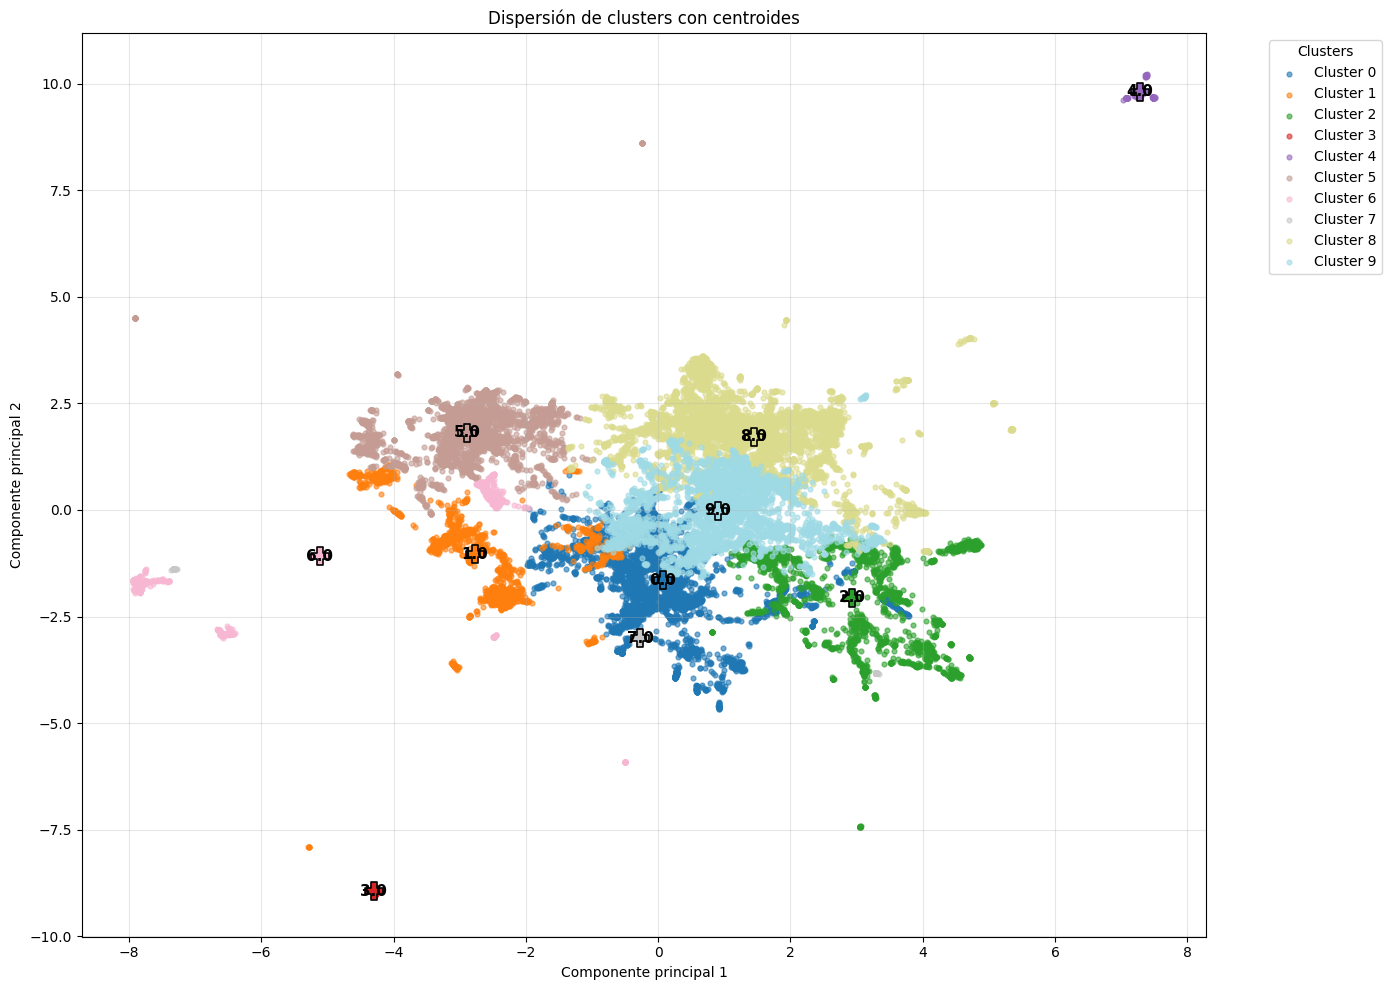

In [5]:
# Reducir embeddings a 2D para visualización
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)
#Crear DataFrame para graficar
df_plot = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "cluster": df_clusters["cluster_kmeans"].values
})
# Calcular centroides visuales
centroides = df_plot.groupby("cluster")[["x", "y"]].mean().reset_index()
# Graficar clusters
plt.figure(figsize=(14, 10))
# Obtener lista ordenada de clusters
clusters_ordenados = sorted(df_plot["cluster"].unique())
# Mapa de colores
cmap = plt.cm.get_cmap("tab20", len(clusters_ordenados))
# Dibujar cada cluster por separado para que la leyenda quede bien
for i, cluster_id in enumerate(clusters_ordenados):
    datos_cluster = df_plot[df_plot["cluster"] == cluster_id]
    
    plt.scatter(
        datos_cluster["x"],
        datos_cluster["y"],
        s=12,
        alpha=0.6,
        color=cmap(i),
        label=f"Cluster {cluster_id}"
    )
# Dibujar centroides
for i, row in centroides.iterrows():
    cluster_id = row["cluster"]
    color_idx = clusters_ordenados.index(cluster_id)
    
    plt.scatter(
        row["x"],
        row["y"],
        s=180,
        color=cmap(color_idx),
        marker="P",
        edgecolors="black",
        linewidths=1.2,
        zorder=5
    )
    
    plt.text(
        row["x"],
        row["y"],
        str(cluster_id),
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        color="black",
        zorder=6
    )
# Detalles finales
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Dispersión de clusters con centroides")
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

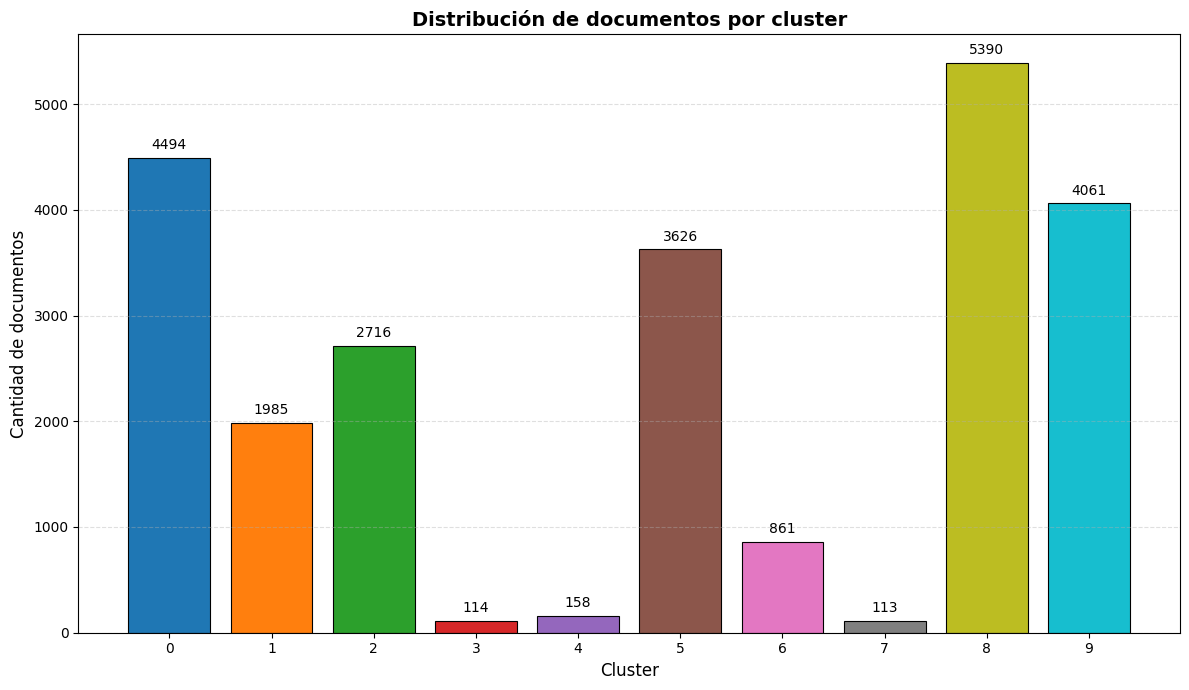

In [16]:
# Conteo de documentos por cluster

conteo_clusters = df_clusters["cluster_kmeans"].value_counts().sort_index()

# Índices y valores
clusters = conteo_clusters.index.tolist()
cantidades = conteo_clusters.values

# Colores diferenciados
colores = plt.cm.tab10(np.linspace(0, 1, len(clusters)))


# Gráfico de barras

plt.figure(figsize=(12, 7))
barras = plt.bar(clusters, cantidades, color=colores, edgecolor="black", linewidth=0.8)

# Etiquetas encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + max(cantidades) * 0.01,   # pequeño desplazamiento vertical
        f"{int(altura)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Títulos y ejes
plt.title("Distribución de documentos por cluster", fontsize=14, fontweight="bold")
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Cantidad de documentos", fontsize=12)

# Marcas del eje X
plt.xticks(clusters, fontsize=10)
plt.yticks(fontsize=10)

# Cuadrícula horizontal sutil
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Ajuste de márgenes
plt.tight_layout()

plt.show()

In [6]:
from wordcloud import WordCloud

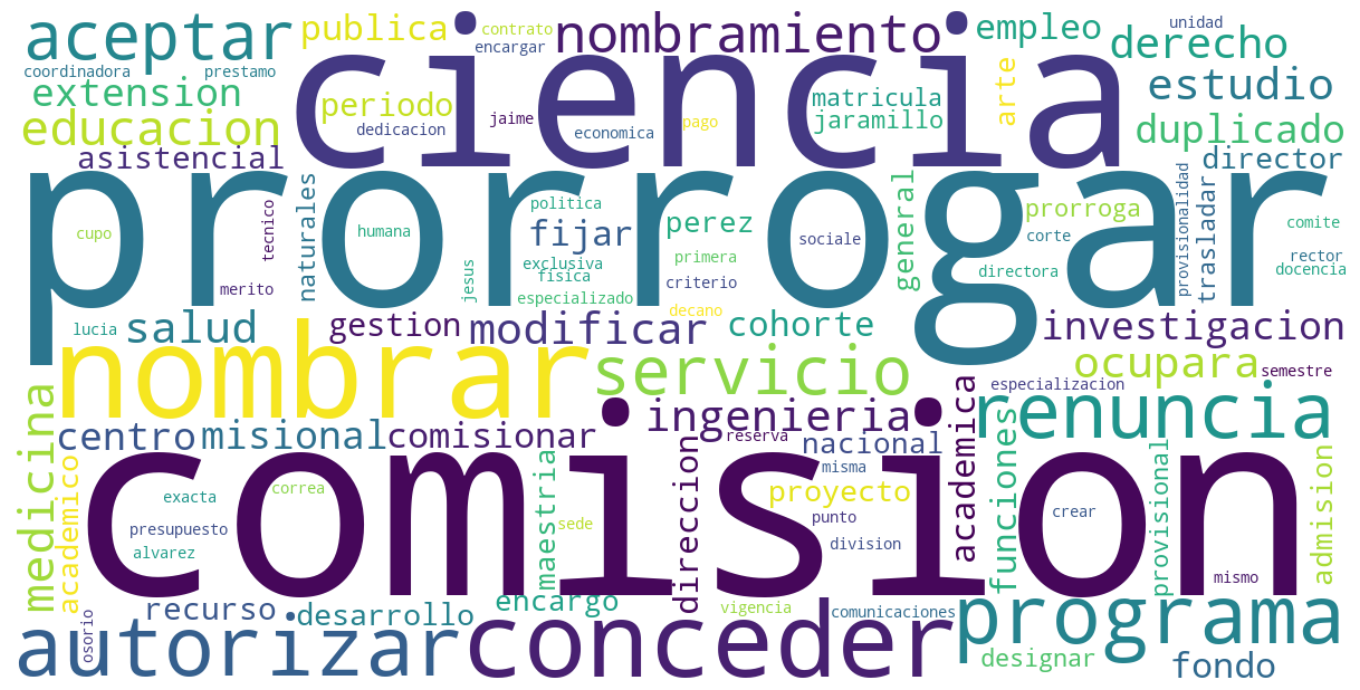

In [18]:
# Unir todos los tokens del DataFrame en un solo texto
texto_general = " ".join(
    " ".join(tokens) for tokens in df_clusters["resuelve_tokens"] if isinstance(tokens, list)
)

# Generar nube de palabras
nube = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False,
    max_words=100
).generate(texto_general)

# Graficar
plt.figure(figsize=(14, 7))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
import os

In [8]:
# Carpeta de salida
carpeta_salida = "nubes_por_cluster_3_2"
os.makedirs(carpeta_salida, exist_ok=True)

# Obtener clusters únicos ordenados
clusters = sorted(df_clusters["cluster_kmeans"].unique())

for cluster_id in clusters:
    # Filtrar textos del cluster
    textos_cluster = df_clusters.loc[
        df_clusters["cluster_kmeans"] == cluster_id,
        "resuelve_tokens"
    ]

    # Unir tokens en un solo texto
    texto_unido = " ".join(
        " ".join(tokens) for tokens in textos_cluster if isinstance(tokens, list)
    )

    # Validar que haya texto
    if not texto_unido.strip():
        print(f"Cluster {cluster_id}: sin texto, no se generó nube.")
        continue

    # Crear nube
    nube = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        collocations=False,
        max_words=60,
        min_font_size=10
    ).generate(texto_unido)

    # Crear figura individual
    plt.figure(figsize=(12, 6))
    plt.imshow(nube, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Nube de palabras - Cluster {cluster_id}", fontsize=16, fontweight="bold")

    # Guardar imagen
    ruta_archivo = os.path.join(carpeta_salida, f"nube_cluster_{cluster_id}.png")
    plt.savefig(ruta_archivo, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Guardada: {ruta_archivo}")

Guardada: nubes_por_cluster_3_2\nube_cluster_0.png
Guardada: nubes_por_cluster_3_2\nube_cluster_1.png
Guardada: nubes_por_cluster_3_2\nube_cluster_2.png
Guardada: nubes_por_cluster_3_2\nube_cluster_3.png
Guardada: nubes_por_cluster_3_2\nube_cluster_4.png
Guardada: nubes_por_cluster_3_2\nube_cluster_5.png
Guardada: nubes_por_cluster_3_2\nube_cluster_6.png
Guardada: nubes_por_cluster_3_2\nube_cluster_7.png
Guardada: nubes_por_cluster_3_2\nube_cluster_8.png
Guardada: nubes_por_cluster_3_2\nube_cluster_9.png
